# Preprocesamiento de Datos - Clustering de Usuarios

Este notebook realiza la **transformación del dataset de transacciones a dataset de usuarios** para el proyecto de clustering.

## Objetivos del preprocesamiento:

1. **Feature Engineering**: Generar variables RFM (Recency, Frequency, Monetary) y comportamiento
2. **Limpieza de outliers**: Detectar y eliminar/ajustar usuarios anómalos con Isolation Forest
3. **Escalado**: Normalizar features con RobustScaler (resistente a outliers)
4. **Encoding**: Codificar variables categóricas con One-Hot Encoding
5. **Reducción de dimensionalidad**: Aplicar PCA manteniendo ≥60% varianza explicada

## Dataset de entrada:
- **Archivo**: `data/interim/interim_ProyClustering/data_sanitized.csv`
- **Estructura**: Dataset de transacciones limpio (1 fila = 1 transacción)
- **Características**: 0 nulos, 0 duplicados, outliers capados, cancelaciones conservadas

## Dataset de salida:
- **Archivo**: `data/processed/data_clustering_pca.csv`
- **Estructura**: Dataset de usuarios (1 fila = 1 usuario/CustomerID)
- **Características**: Features escaladas, reducidas con PCA, listas para clustering

---
## 0. Imports, Configuración y Carga del Dataset Limpio

Preparamos el entorno de trabajo:
- Importamos todas las librerías necesarias para preprocesamiento y clustering
- Configuramos la estética visual global
- Definimos las rutas del proyecto
- Cargamos el dataset limpio de transacciones
- Verificamos que el dataset está correcto (dimensiones, nulos, duplicados)

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 0. IMPORTS Y CONFIGURACIÓN
# ══════════════════════════════════════════════════════════════════════════════

# ── Librerías básicas ─────────────────────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Visualización ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# ── Preprocesamiento y escalado ───────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

# ── Reducción de dimensionalidad ──────────────────────────────────────────────
from sklearn.decomposition import PCA

# ── Detección de anomalías ────────────────────────────────────────────────────
from sklearn.ensemble import IsolationForest

# ── Persistencia de modelos ───────────────────────────────────────────────────
import joblib

# ── Configuración visual global ───────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10
%matplotlib inline

# ── Configuración de pandas ───────────────────────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print('[OK] Librerías importadas correctamente')
print(f'\nVersiones:')
print(f'   - pandas: {pd.__version__}')
print(f'   - numpy: {np.__version__}')
print(f'   - matplotlib: {plt.matplotlib.__version__}')
print(f'   - seaborn: {sns.__version__}')

✅ Librerías importadas correctamente

📦 Versiones:
   - pandas: 3.0.2
   - numpy: 2.4.4
   - matplotlib: 3.10.8
   - seaborn: 0.13.2


In [ ]:
# ── Rutas del proyecto ───────────────────────────────────────────────────────

# Ruta del dataset limpio (input)
RUTA_DATA_LIMPIA = '../../../data/interim/interim_ProyClustering/data_sanitized.csv'

# Rutas de salida
RUTA_PROCESSED = '../../../data/processed/'
RUTA_GRAFICOS  = '../../../graphics/gr_clustering/preprocesing/'
RUTA_MODELS    = '../../../models/'

# Crear directorios si no existen
os.makedirs(RUTA_PROCESSED, exist_ok=True)
os.makedirs(RUTA_GRAFICOS, exist_ok=True)
os.makedirs(RUTA_MODELS, exist_ok=True)

print('[OK] Rutas configuradas correctamente')
print(f'\nEstructura de directorios:')
print(f'   Input:')
print(f'   - Dataset limpio      : {RUTA_DATA_LIMPIA}')
print(f'\n   Output:')
print(f'   - Datos procesados    : {RUTA_PROCESSED}')
print(f'   - Gráficos            : {RUTA_GRAFICOS}')
print(f'   - Modelos (scalers)   : {RUTA_MODELS}')

✅ Rutas configuradas correctamente

📂 Estructura de directorios:
   Input:
   - Dataset limpio      : ../../../data/interim/interim_ProyClustering/data_sanitized.csv

   Output:
   - Datos procesados    : ../../../data/processed/
   - Gráficos            : ../../../graphics/gr_clustering/preprocesing/
   - Modelos (scalers)   : ../../../models/


In [ ]:
# ── Carga del dataset limpio ─────────────────────────────────────────────────

print('='*80)
print('  CARGA DEL DATASET LIMPIO')
print('='*80)
print()
print(f'Cargando desde: {RUTA_DATA_LIMPIA}')
print()

# Cargar el dataset
df_transacciones = pd.read_csv(RUTA_DATA_LIMPIA)

# Convertir columnas de fecha a datetime
df_transacciones['InvoiceDate'] = pd.to_datetime(df_transacciones['InvoiceDate'])
df_transacciones['Fecha'] = pd.to_datetime(df_transacciones['Fecha'])
df_transacciones['Mes'] = df_transacciones['Mes'].astype(str)

print(f'[OK] Dataset cargado correctamente')
print()
print(f'{'─'*80}')
print(f'  DIMENSIONES DEL DATASET')
print(f'{'─'*80}')
print(f'  Filas (transacciones)     : {len(df_transacciones):>15,}')
print(f'  Columnas                  : {len(df_transacciones.columns):>15}')
print(f'  Tamaño en memoria         : {df_transacciones.memory_usage(deep=True).sum() / 1024**2:>15,.2f} MB')
print(f'{'─'*80}')
print()
print(f'  COLUMNAS DISPONIBLES ({len(df_transacciones.columns)}):')
for i, col in enumerate(df_transacciones.columns, 1):
    dtype = str(df_transacciones[col].dtype)
    print(f'    {i:>2}. {col:<20} ({dtype})')
print()
print('='*80)

  CARGA DEL DATASET LIMPIO

📂 Cargando desde: ../../../data/interim/interim_ProyClustering/data_sanitized.csv

✅ Dataset cargado correctamente

────────────────────────────────────────────────────────────────────────────────
  DIMENSIONES DEL DATASET
────────────────────────────────────────────────────────────────────────────────
  Filas (transacciones)     :         399,651
  Columnas                  :              13
  Tamaño en memoria         :          155.56 MB
────────────────────────────────────────────────────────────────────────────────

  COLUMNAS DISPONIBLES (13):
     1. InvoiceNo            (str)
     2. StockCode            (str)
     3. Description          (str)
     4. Quantity             (int64)
     5. InvoiceDate          (datetime64[us])
     6. UnitPrice            (float64)
     7. CustomerID           (float64)
     8. Country              (str)
     9. Fecha                (datetime64[us])
    10. Mes                  (str)
    11. DiaSemana            (str)

In [ ]:
# ── Verificación de calidad del dataset ──────────────────────────────────────

print('='*80)
print('  VERIFICACIÓN DE CALIDAD DEL DATASET')
print('='*80)
print()

# ── Verificación 1: Valores nulos ─────────────────────────────────────────────
nulos_total = df_transacciones.isnull().sum().sum()
nulos_por_columna = df_transacciones.isnull().sum()

print(f'  ✓ VERIFICACIÓN 1: VALORES NULOS')
print(f'  {'─'*78}')
print(f'     Total valores nulos       : {nulos_total:>10,}')
if nulos_total > 0:
    print(f'     [!] ATENCIÓN: Hay valores nulos en el dataset')
    print(f'\n     Columnas con nulos:')
    for col, count in nulos_por_columna[nulos_por_columna > 0].items():
        pct = (count / len(df_transacciones) * 100)
        print(f'       - {col:<20} : {count:>8,} ({pct:>6.2f}%)')
else:
    print(f'     [OK] No hay valores nulos')
print()

# ── Verificación 2: Duplicados ────────────────────────────────────────────────
duplicados = df_transacciones.duplicated().sum()

print(f'  ✓ VERIFICACIÓN 2: DUPLICADOS EXACTOS')
print(f'  {'─'*78}')
print(f'     Filas duplicadas          : {duplicados:>10,}')
if duplicados > 0:
    print(f'     [!] ATENCIÓN: Hay {duplicados:,} filas duplicadas')
else:
    print(f'     [OK] No hay duplicados')
print()

# ── Verificación 3: CustomerID únicos ─────────────────────────────────────────
num_usuarios = df_transacciones['CustomerID'].nunique()
customerid_nulos = df_transacciones['CustomerID'].isnull().sum()

print(f'  ✓ VERIFICACIÓN 3: CUSTOMERID (crítico para clustering)')
print(f'  {'─'*78}')
print(f'     Usuarios únicos (CustomerID) : {num_usuarios:>10,}')
print(f'     CustomerID nulos             : {customerid_nulos:>10,}')
if customerid_nulos > 0:
    print(f'     [ERROR] Hay CustomerID nulos → no se puede hacer clustering')
else:
    print(f'     [OK] Todos los registros tienen CustomerID')
print()

# ── Verificación 4: Distribución básica ───────────────────────────────────────
num_productos = df_transacciones['StockCode'].nunique()
num_facturas = df_transacciones['InvoiceNo'].nunique()
num_paises = df_transacciones['Country'].nunique()

print(f'  ✓ VERIFICACIÓN 4: ENTIDADES ÚNICAS')
print(f'  {'─'*78}')
print(f'     Usuarios (CustomerID)     : {num_usuarios:>10,}')
print(f'     Productos (StockCode)     : {num_productos:>10,}')
print(f'     Facturas (InvoiceNo)      : {num_facturas:>10,}')
print(f'     Países                    : {num_paises:>10,}')
print()

# ── Verificación 5: Rango temporal ────────────────────────────────────────────
fecha_min = df_transacciones['InvoiceDate'].min()
fecha_max = df_transacciones['InvoiceDate'].max()
dias_totales = (fecha_max - fecha_min).days

print(f'  ✓ VERIFICACIÓN 5: COBERTURA TEMPORAL')
print(f'  {'─'*78}')
print(f'     Fecha inicio              : {fecha_min.strftime("%Y-%m-%d")}')
print(f'     Fecha fin                 : {fecha_max.strftime("%Y-%m-%d")}')
print(f'     Duración                  : {dias_totales} días')
print()

# ── Resumen de validación ─────────────────────────────────────────────────────
print(f'{'='*80}')
errores = []
if nulos_total > 0:
    errores.append('Valores nulos detectados')
if duplicados > 0:
    errores.append('Duplicados detectados')
if customerid_nulos > 0:
    errores.append('CustomerID nulos (CRÍTICO)')

if len(errores) == 0:
    print(f'  [OK] DATASET VALIDADO CORRECTAMENTE')
    print(f'  {'─'*78}')
    print(f'     El dataset está limpio y listo para preprocesamiento')
    print(f'     Próximo paso: Generar features de usuario (RFM + comportamiento)')
else:
    print(f'  [ERROR] ERRORES DETECTADOS EN EL DATASET')
    print(f'  {'─'*78}')
    for error in errores:
        print(f'     • {error}')
    print(f'\n     [!] Revisar el notebook de limpieza antes de continuar')

print(f'{'='*80}')

  VERIFICACIÓN DE CALIDAD DEL DATASET

  ✓ VERIFICACIÓN 1: VALORES NULOS
  ──────────────────────────────────────────────────────────────────────────────
     Total valores nulos       :          0
     ✅ OK: No hay valores nulos

  ✓ VERIFICACIÓN 2: DUPLICADOS EXACTOS
  ──────────────────────────────────────────────────────────────────────────────
     Filas duplicadas          :          0
     ✅ OK: No hay duplicados

  ✓ VERIFICACIÓN 3: CUSTOMERID (crítico para clustering)
  ──────────────────────────────────────────────────────────────────────────────
     Usuarios únicos (CustomerID) :      4,362
     CustomerID nulos             :          0
     ✅ OK: Todos los registros tienen CustomerID

  ✓ VERIFICACIÓN 4: ENTIDADES ÚNICAS
  ──────────────────────────────────────────────────────────────────────────────
     Usuarios (CustomerID)     :      4,362
     Productos (StockCode)     :      3,676
     Facturas (InvoiceNo)      :     21,785
     Países                    :         37

In [ ]:
# ── Vista previa del dataset ─────────────────────────────────────────────────

print('\nVISTA PREVIA DEL DATASET (primeras 10 filas):')
print('='*80)
display(df_transacciones.head(10))

print('\nESTADÍSTICAS DESCRIPTIVAS (columnas numéricas):')
print('='*80)
display(df_transacciones.describe())

print('\nINFORMACIÓN DEL DATAFRAME:')
print('='*80)
df_transacciones.info()


👁️  VISTA PREVIA DEL DATASET (primeras 10 filas):


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Fecha,Mes,DiaSemana,EsCancelacion,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.00,United Kingdom,2010-12-01,2010-12,Wednesday,False,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom,2010-12-01,2010-12,Wednesday,False,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.00,United Kingdom,2010-12-01,2010-12,Wednesday,False,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom,2010-12-01,2010-12,Wednesday,False,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom,2010-12-01,2010-12,Wednesday,False,20.34
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.00,United Kingdom,2010-12-01,2010-12,Wednesday,False,15.30
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.00,United Kingdom,2010-12-01,2010-12,Wednesday,False,25.50
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.00,United Kingdom,2010-12-01,2010-12,Wednesday,False,11.10
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.00,United Kingdom,2010-12-01,2010-12,Wednesday,False,11.10
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.00,United Kingdom,2010-12-01,2010-12,Wednesday,False,54.08



📊 ESTADÍSTICAS DESCRIPTIVAS (columnas numéricas):


,Quantity,InvoiceDate,UnitPrice,CustomerID,Fecha,TotalPrice
count,399651.00,399651,399651.00,399651.00,399651,399651.00
mean,10.63,2011-07-10 12:36:01.626669,2.80,15288.78,2011-07-09 23:21:41.266354,18.53
min,-120.00,2010-12-01 08:26:00,0.03,12346.00,2010-12-01 00:00:00,-1314.00
25%,2.00,2011-04-06 15:07:00,1.25,13959.00,2011-04-06 00:00:00,4.25
50%,5.00,2011-07-29 15:51:00,1.95,15152.00,2011-07-29 00:00:00,11.56
75%,12.00,2011-10-20 12:03:00,3.75,16791.00,2011-10-20 00:00:00,19.50
max,120.00,2011-12-09 12:50:00,12.75,18287.00,2011-12-09 00:00:00,1530.00
std,18.43,NaN,2.65,1710.78,NaN,38.08



📋 INFORMACIÓN DEL DATAFRAME:
<class 'pandas.DataFrame'>
RangeIndex: 399651 entries, 0 to 399650
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   InvoiceNo      399651 non-null  str           
 1   StockCode      399651 non-null  str           
 2   Description    399651 non-null  str           
 3   Quantity       399651 non-null  int64         
 4   InvoiceDate    399651 non-null  datetime64[us]
 5   UnitPrice      399651 non-null  float64       
 6   CustomerID     399651 non-null  float64       
 7   Country        399651 non-null  str           
 8   Fecha          399651 non-null  datetime64[us]
 9   Mes            399651 non-null  str           
 10  DiaSemana      399651 non-null  str           
 11  EsCancelacion  399651 non-null  bool          
 12  TotalPrice     399651 non-null  float64       
dtypes: bool(1), datetime64[us](2), float64(3), int64(1), str(6)
memory usage: 37.0 MB



## SIGUIENTE PASO: PASO 4 - GENERACIÓN DE FEATURES

**Objetivo**: Transformar dataset de transacciones → dataset de usuarios

En el siguiente paso crearemos:
1. **Variables RFM** (Recency, Frequency, Monetary)
2. **Variables de comportamiento** (ticket promedio, diversidad productos, gasto mensual)
3. **Variables de cancelación** (tasa devolución, ratio devuelto)
4. **Variables temporales** (día preferido, fin de semana)
5. **Variable geográfica** (país)

**Resultado esperado**: DataFrame con ~4,400 filas (1 fila por usuario) y 10-15 features

## PASO 4.1: Variables RFM (Recency, Frequency, Monetary)

**RFM** es el core del análisis de clustering en e-commerce:
- **R** (Recency): ¿Cuándo fue la última compra?
- **F** (Frequency): ¿Con qué frecuencia compra?
- **M** (Monetary): ¿Cuánto gasta en total?

---

### 4.1.A — RECENCY (Recencia)

**Definición**: Días transcurridos desde la última compra del usuario

**Interpretación**:
- Recency **bajo** (ej. 5 días) → Cliente activo, compró recientemente
- Recency **alto** (ej. 200 días) → Cliente inactivo, lleva mucho sin comprar

**Cálculo**:
```
Recency = fecha_referencia - max(InvoiceDate por usuario)
```

**Fecha de referencia**: Última fecha del dataset + 1 día  
(Simula que estamos analizando el día después del último registro)

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#   PASO 4.1.A: CÁLCULO DE RECENCY (RECENCIA)
# ══════════════════════════════════════════════════════════════════════════════

print('='*80)
print('  PASO 4.1.A: RECENCY (Recencia)')
print('='*80)
print()

# ── 1. Determinar la fecha de referencia ─────────────────────────────────────
fecha_ultima_transaccion = df_transacciones['InvoiceDate'].max()
fecha_referencia = fecha_ultima_transaccion + pd.Timedelta(days=1)

print(f'FECHAS DE REFERENCIA:')
print(f'  {'─'*78}')
print(f'     Última transacción del dataset : {fecha_ultima_transaccion.strftime("%Y-%m-%d")}')
print(f'     Fecha de referencia (+ 1 día)  : {fecha_referencia.strftime("%Y-%m-%d")}')
print()

# ── 2. Calcular la última compra por usuario ─────────────────────────────
print(f'Calculando última compra por usuario...')
ultima_compra_por_usuario = df_transacciones.groupby('CustomerID')['InvoiceDate'].max()

print(f'   [OK] Calculado para {len(ultima_compra_por_usuario):,} usuarios')
print()

# ── 3. Calcular Recency (días desde la última compra) ────────────────────────
print(f'Calculando Recency (días desde última compra)...')
recency_por_usuario = (fecha_referencia - ultima_compra_por_usuario).dt.days

print(f'   [OK] Recency calculado para {len(recency_por_usuario):,} usuarios')
print()

# ── 4. Crear DataFrame con Recency ───────────────────────────────────────────
df_rfm = pd.DataFrame({
    'CustomerID': recency_por_usuario.index,
    'Recency': recency_por_usuario.values
})

print(f'[OK] DataFrame RFM creado')
print(f'  {'─'*78}')
print(f'     Dimensiones : {df_rfm.shape[0]:,} usuarios × {df_rfm.shape[1]} columnas')
print(f'     Columnas    : {list(df_rfm.columns)}')
print()

# ── 5. Estadísticas descriptivas de Recency ──────────────────────────────
print(f'ESTADÍSTICAS DE RECENCY:')
print(f'  {'─'*78}')
print(f'     Mínimo         : {df_rfm["Recency"].min():>8} días  (usuario compró recientemente)')
print(f'     Máximo         : {df_rfm["Recency"].max():>8} días  (usuario inactivo hace tiempo)')
print(f'     Media          : {df_rfm["Recency"].mean():>8.2f} días')
print(f'     Mediana        : {df_rfm["Recency"].median():>8.0f} días')
print(f'     Desv. estándar : {df_rfm["Recency"].std():>8.2f} días')
print()

print(f'  Percentiles:')
print(f'     P25 (Q1)       : {df_rfm["Recency"].quantile(0.25):>8.0f} días')
print(f'     P50 (Mediana)  : {df_rfm["Recency"].quantile(0.50):>8.0f} días')
print(f'     P75 (Q3)       : {df_rfm["Recency"].quantile(0.75):>8.0f} días')
print(f'     P90            : {df_rfm["Recency"].quantile(0.90):>8.0f} días')
print(f'     P95            : {df_rfm["Recency"].quantile(0.95):>8.0f} días')
print(f'     P99            : {df_rfm["Recency"].quantile(0.99):>8.0f} días')

print()
print('='*80)

  PASO 4.1.A: RECENCY (Recencia)

📅 FECHAS DE REFERENCIA:
  ──────────────────────────────────────────────────────────────────────────────
     Última transacción del dataset : 2011-12-09
     Fecha de referencia (+ 1 día)  : 2011-12-10

🔄 Calculando última compra por usuario...
   ✅ Calculado para 4,362 usuarios

🔄 Calculando Recency (días desde última compra)...
   ✅ Recency calculado para 4,362 usuarios

✅ DataFrame RFM creado
  ──────────────────────────────────────────────────────────────────────────────
     Dimensiones : 4,362 usuarios × 2 columnas
     Columnas    : ['CustomerID', 'Recency']

📊 ESTADÍSTICAS DE RECENCY:
  ──────────────────────────────────────────────────────────────────────────────
     Mínimo         :        1 días  (usuario compró recientemente)
     Máximo         :      374 días  (usuario inactivo hace tiempo)
     Media          :    92.17 días
     Mediana        :       50 días
     Desv. estándar :   100.97 días

  Percentiles:
     P25 (Q1)       :   

In [ ]:
# ── Vista previa del DataFrame RFM (con Recency) ─────────────────────────────

print('\nVISTA PREVIA DEL DATAFRAME RFM (primeras 20 filas):')
print('='*80)
print()

# Mostrar ordenado por Recency (los más recientes primero)
print('TOP 10: Usuarios más ACTIVOS (Recency más bajo - compraron recientemente):')
display(df_rfm.nsmallest(10, 'Recency'))

print()
print('[!] TOP 10: Usuarios más INACTIVOS (Recency más alto - llevan sin comprar):')
display(df_rfm.nlargest(10, 'Recency'))

print()
print('Muestra aleatoria de 10 usuarios:')
display(df_rfm.sample(10).sort_values('Recency'))


👁️  VISTA PREVIA DEL DATAFRAME RFM (primeras 20 filas):

🔝 TOP 10: Usuarios más ACTIVOS (Recency más bajo - compraron recientemente):


,CustomerID,Recency
61,12423.00,1
71,12433.00,1
105,12476.00,1
137,12518.00,1
144,12526.00,1
259,12662.00,1
273,12680.00,1
299,12713.00,1
328,12748.00,1
475,12955.00,1



⚠️  TOP 10: Usuarios más INACTIVOS (Recency más alto - llevan sin comprar):


,CustomerID,Recency
357,12791.00,374
1042,13747.00,374
1760,14729.00,374
3122,16583.00,374
4086,17908.00,374
4130,17968.00,374
4202,18074.00,374
404,12855.00,373
550,13065.00,373
582,13108.00,373



📋 Muestra aleatoria de 10 usuarios:


,CustomerID,Recency
3739,17434.00,2
3649,17317.00,46
3794,17513.00,72
1974,15036.00,72
993,13682.00,187
4311,18220.00,220
1900,14924.00,246
2124,15226.00,311
2157,15266.00,338
3428,16995.00,372



📊 VISUALIZACIÓN: Distribución de Recency

✅ Gráfico guardado en: ../../../graphics/gr_clustering/preprocesing/4.1.A_distribucion_recency.png


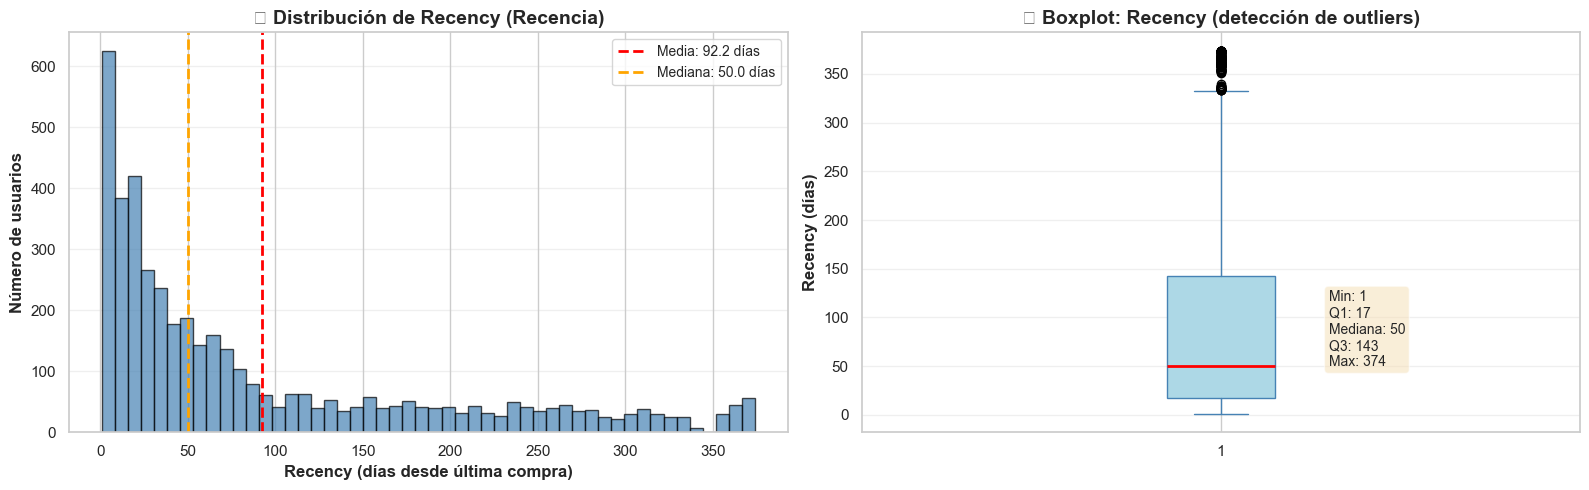

In [ ]:
# ── Visualización de la distribución de Recency ──────────────────────────────

print('\nVISUALIZACIÓN: Distribución de Recency')
print('='*80)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Gráfico 1: Histograma ─────────────────────────────────────────────
axes[0].hist(df_rfm['Recency'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df_rfm['Recency'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df_rfm["Recency"].mean():.1f} días')
axes[0].axvline(df_rfm['Recency'].median(), color='orange', linestyle='--', linewidth=2, label=f'Mediana: {df_rfm["Recency"].median():.1f} días')
axes[0].set_xlabel('Recency (días desde última compra)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Número de usuarios', fontsize=12, fontweight='bold')
axes[0].set_title('Distribución de Recency (Recencia)', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# ── Gráfico 2: Boxplot ────────────────────────────────────────────────────────
axes[1].boxplot(df_rfm['Recency'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='steelblue'),
                whiskerprops=dict(color='steelblue'),
                capprops=dict(color='steelblue'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('Recency (días)', fontsize=12, fontweight='bold')
axes[1].set_title('Boxplot: Recency (detección de outliers)', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Añadir estadísticas al boxplot
stats_text = f'Min: {df_rfm["Recency"].min():.0f}\nQ1: {df_rfm["Recency"].quantile(0.25):.0f}\nMediana: {df_rfm["Recency"].median():.0f}\nQ3: {df_rfm["Recency"].quantile(0.75):.0f}\nMax: {df_rfm["Recency"].max():.0f}'
axes[1].text(1.15, df_rfm['Recency'].median(), stats_text, fontsize=10, 
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()

# Guardar gráfico
ruta_grafico = os.path.join(RUTA_GRAFICOS, '4.1.A_distribucion_recency.png')
plt.savefig(ruta_grafico, dpi=300, bbox_inches='tight')
print(f'\n[OK] Gráfico guardado en: {ruta_grafico}')

plt.show()

print('\n' + '='*80)

---

### 4.1.B — FREQUENCY (Frecuencia)

**Definición**: Número total de transacciones (compras únicas) del usuario

**Interpretación**:
- Frequency **bajo** (ej. 1-2 compras) → Cliente ocasional, una sola compra
- Frequency **alto** (ej. 50+ compras) → Cliente frecuente/fiel, compra regularmente

**Cálculo**:
```
Frequency = count(InvoiceNo único por usuario)
```

**Nota importante**: Contamos facturas únicas (`InvoiceNo`), no líneas de transacción. Una factura puede tener múltiples productos.

**Filtro de cancelaciones**: Solo contamos facturas de compra (no cancelaciones que empiezan con 'C')

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#   PASO 4.1.B: CÁLCULO DE FREQUENCY (FRECUENCIA)
# ══════════════════════════════════════════════════════════════════════════════

print('='*80)
print('  PASO 4.1.B: FREQUENCY (Frecuencia)')
print('='*80)
print()

# ── 1. Filtrar solo transacciones de compra (sin cancelaciones) ──────────────
print(f'Filtrando transacciones...')
print(f'  {'─'*78}')

# Total de transacciones
total_transacciones = len(df_transacciones)
print(f'     Total transacciones (todas)       : {total_transacciones:>10,}')

# Filtrar cancelaciones (InvoiceNo que NO empiezan con 'C')
df_compras = df_transacciones[~df_transacciones['InvoiceNo'].astype(str).str.startswith('C')]
transacciones_compra = len(df_compras)
print(f'     Transacciones de COMPRA           : {transacciones_compra:>10,}')

# Calcular cancelaciones
transacciones_cancelacion = total_transacciones - transacciones_compra
pct_cancelacion = (transacciones_cancelacion / total_transacciones * 100)
print(f'     Transacciones de CANCELACIÓN      : {transacciones_cancelacion:>10,} ({pct_cancelacion:.2f}%)')
print()

# ── 2. Calcular el número de facturas únicas por usuario ─────────────────────
print(f'Calculando número de facturas únicas por usuario...')

# Contar facturas únicas (InvoiceNo) por CustomerID
frequency_por_usuario = df_compras.groupby('CustomerID')['InvoiceNo'].nunique()

print(f'   [OK] Frequency calculado para {len(frequency_por_usuario):,} usuarios')
print()

# ── 3. Agregar Frequency al DataFrame RFM ─────────────────────────────
print(f'Agregando Frequency al DataFrame RFM...')

# Merge con df_rfm
df_rfm = df_rfm.merge(
    frequency_por_usuario.rename('Frequency'),
    left_on='CustomerID',
    right_index=True,
    how='left'
)

# Rellenar con 0 si hay usuarios sin compras (solo cancelaciones)
df_rfm['Frequency'] = df_rfm['Frequency'].fillna(0).astype(int)

print(f'   [OK] Frequency agregado correctamente')
print()

print(f'[OK] DataFrame RFM actualizado')
print(f'  {'─'*78}')
print(f'     Dimensiones : {df_rfm.shape[0]:,} usuarios × {df_rfm.shape[1]} columnas')
print(f'     Columnas    : {list(df_rfm.columns)}')
print()

# ── 4. Estadísticas descriptivas de Frequency ─────────────────────────────────
print(f'ESTADÍSTICAS DE FREQUENCY:')
print(f'  {'─'*78}')
print(f'     Mínimo         : {df_rfm["Frequency"].min():>8} compras  (cliente de 1 sola compra)')
print(f'     Máximo         : {df_rfm["Frequency"].max():>8} compras  (cliente super frecuente)')
print(f'     Media          : {df_rfm["Frequency"].mean():>8.2f} compras')
print(f'     Mediana        : {df_rfm["Frequency"].median():>8.0f} compras')
print(f'     Desv. estándar : {df_rfm["Frequency"].std():>8.2f} compras')
print()

print(f'  Percentiles:')
print(f'     P25 (Q1)       : {df_rfm["Frequency"].quantile(0.25):>8.0f} compras')
print(f'     P50 (Mediana)  : {df_rfm["Frequency"].quantile(0.50):>8.0f} compras')
print(f'     P75 (Q3)       : {df_rfm["Frequency"].quantile(0.75):>8.0f} compras')
print(f'     P90            : {df_rfm["Frequency"].quantile(0.90):>8.0f} compras')
print(f'     P95            : {df_rfm["Frequency"].quantile(0.95):>8.0f} compras')
print(f'     P99            : {df_rfm["Frequency"].quantile(0.99):>8.0f} compras')
print()

# ── 5. Distribución de usuarios por rango de Frequency ───────────────────────
print(f'DISTRIBUCIÓN DE USUARIOS POR RANGO DE FREQUENCY:')
print(f'  {'─'*78}')

# Definir rangos
bins = [0, 1, 5, 10, 20, 50, 100, float('inf')]
labels = ['1 compra', '2-5 compras', '6-10 compras', '11-20 compras', '21-50 compras', '51-100 compras', '100+ compras']
df_rfm['Frequency_Range'] = pd.cut(df_rfm['Frequency'], bins=bins, labels=labels, right=True)

# Calcular distribución
distribucion = df_rfm['Frequency_Range'].value_counts().sort_index()

for rango, count in distribucion.items():
    pct = (count / len(df_rfm) * 100)
    print(f'     {str(rango):<20} : {count:>6,} usuarios ({pct:>6.2f}%)')

# Eliminar columna temporal
df_rfm.drop('Frequency_Range', axis=1, inplace=True)

print()
print('='*80)

  PASO 4.1.B: FREQUENCY (Frecuencia)

🔄 Filtrando transacciones...
  ──────────────────────────────────────────────────────────────────────────────
     Total transacciones (todas)       :    399,651
     Transacciones de COMPRA           :    391,145
     Transacciones de CANCELACIÓN      :      8,506 (2.13%)

🔄 Calculando número de facturas únicas por usuario...
   ✅ Frequency calculado para 4,334 usuarios

🔄 Agregando Frequency al DataFrame RFM...
   ✅ Frequency agregado correctamente

✅ DataFrame RFM actualizado
  ──────────────────────────────────────────────────────────────────────────────
     Dimensiones : 4,362 usuarios × 3 columnas
     Columnas    : ['CustomerID', 'Recency', 'Frequency']

📊 ESTADÍSTICAS DE FREQUENCY:
  ──────────────────────────────────────────────────────────────────────────────
     Mínimo         :        0 compras  (cliente de 1 sola compra)
     Máximo         :      206 compras  (cliente super frecuente)
     Media          :     4.22 compras
     Medi

In [ ]:
# ── Vista previa del DataFrame RFM (con Recency + Frequency) ─────────────────

print('\nVISTA PREVIA DEL DATAFRAME RFM (con Recency + Frequency):')
print('='*80)
print()

# Mostrar ordenado por Frequency (los más frecuentes primero)
print('TOP 10: Usuarios más FRECUENTES (Frequency más alto):')
display(df_rfm.nsmallest(10, 'Recency').nlargest(10, 'Frequency'))

print()
print('[!] TOP 10: Usuarios OCASIONALES (Frequency más bajo - 1 sola compra):')
display(df_rfm.nsmallest(10, 'Frequency').head(10))

print()
print('Muestra aleatoria de 10 usuarios:')
display(df_rfm.sample(10).sort_values('Frequency', ascending=False))


👁️  VISTA PREVIA DEL DATAFRAME RFM (con Recency + Frequency):

🔝 TOP 10: Usuarios más FRECUENTES (Frequency más alto):


,CustomerID,Recency,Frequency
328,12748.00,1,206
105,12476.00,1,11
259,12662.00,1,11
475,12955.00,1,11
61,12423.00,1,8
71,12433.00,1,7
137,12518.00,1,5
273,12680.00,1,4
144,12526.00,1,3
299,12713.00,1,1



⚠️  TOP 10: Usuarios OCASIONALES (Frequency más bajo - 1 sola compra):


,CustomerID,Recency,Frequency
210,12605.00,365,0
262,12666.00,359,0
413,12870.00,366,0
465,12943.00,301,0
1000,13693.00,325,0
1102,13829.00,359,0
1196,13958.00,372,0
1314,14119.00,354,0
1380,14213.00,372,0
1684,14627.00,312,0



📋 Muestra aleatoria de 10 usuarios:


,CustomerID,Recency,Frequency
2556,15805.00,23,17
2598,15858.00,16,5
3554,17175.00,44,4
2418,15621.00,4,4
459,12936.00,17,4
2817,16164.00,17,3
1602,14514.00,61,3
2311,15478.00,40,2
1374,14206.00,239,1
3713,17403.00,36,1



📊 VISUALIZACIÓN: Distribución de Frequency

✅ Gráfico guardado en: ../../../graphics/gr_clustering/preprocesing/4.1.B_distribucion_frequency.png


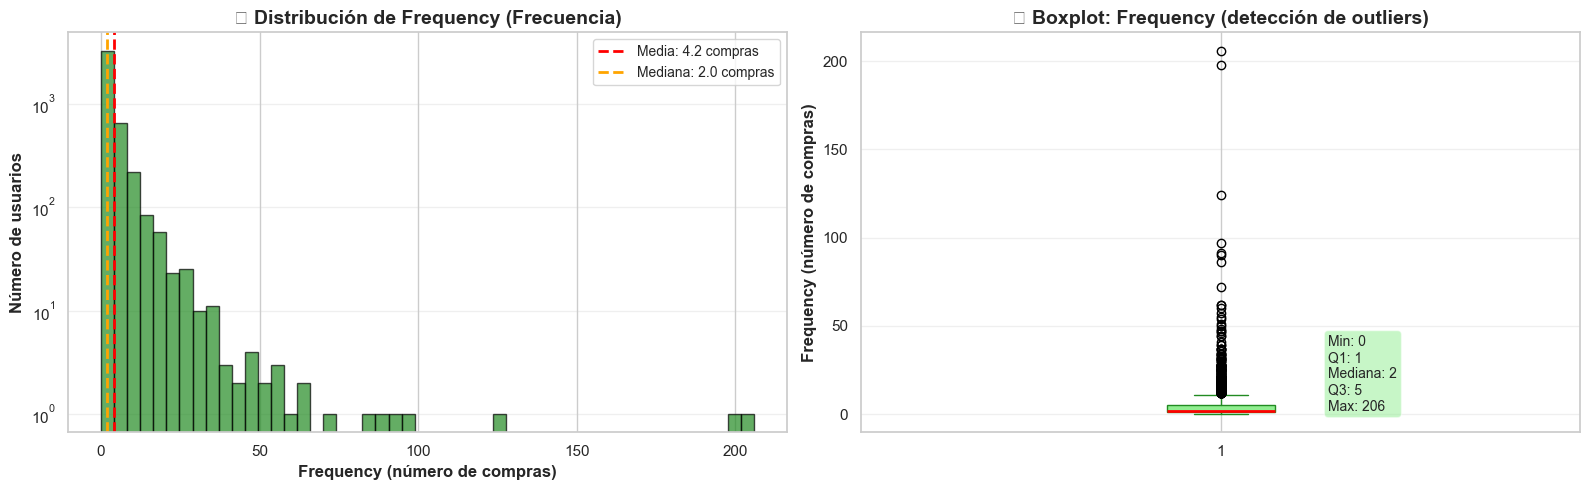

In [ ]:
# ── Visualización de la distribución de Frequency ────────────────────────────

print('\nVISUALIZACIÓN: Distribución de Frequency')
print('='*80)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Gráfico 1: Histograma (escala logarítmica en Y) ───────────────────────
axes[0].hist(df_rfm['Frequency'], bins=50, color='forestgreen', edgecolor='black', alpha=0.7)
axes[0].axvline(df_rfm['Frequency'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df_rfm["Frequency"].mean():.1f} compras')
axes[0].axvline(df_rfm['Frequency'].median(), color='orange', linestyle='--', linewidth=2, label=f'Mediana: {df_rfm["Frequency"].median():.1f} compras')
axes[0].set_xlabel('Frequency (número de compras)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Número de usuarios', fontsize=12, fontweight='bold')
axes[0].set_title('Distribución de Frequency (Frecuencia)', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)
# Escala logarítmica en Y si hay mucha concentración en valores bajos
axes[0].set_yscale('log')

# ── Gráfico 2: Boxplot ────────────────────────────────────────────────────────
axes[1].boxplot(df_rfm['Frequency'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightgreen', color='forestgreen'),
                whiskerprops=dict(color='forestgreen'),
                capprops=dict(color='forestgreen'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('Frequency (número de compras)', fontsize=12, fontweight='bold')
axes[1].set_title('Boxplot: Frequency (detección de outliers)', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Añadir estadísticas al boxplot
stats_text = f'Min: {df_rfm["Frequency"].min():.0f}\nQ1: {df_rfm["Frequency"].quantile(0.25):.0f}\nMediana: {df_rfm["Frequency"].median():.0f}\nQ3: {df_rfm["Frequency"].quantile(0.75):.0f}\nMax: {df_rfm["Frequency"].max():.0f}'
axes[1].text(1.15, df_rfm['Frequency'].median(), stats_text, fontsize=10, 
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

plt.tight_layout()

# Guardar gráfico
ruta_grafico = os.path.join(RUTA_GRAFICOS, '4.1.B_distribucion_frequency.png')
plt.savefig(ruta_grafico, dpi=300, bbox_inches='tight')
print(f'\n[OK] Gráfico guardado en: {ruta_grafico}')

plt.show()

print('\n' + '='*80)